# 02 EDA - Column Analysis

Quick Facts: 

- 7853 unique firms
- year range 2005 - 2018 (14 years total)
- majority of unique firms has data for either 1 year or 14 years in singular year comparison 


In [1]:
# this file is used to find the project root and set the working directory to it.
from pathlib import Path
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt




In [2]:
def find_project_root(marker=".project-root"):
    path = Path.cwd().resolve()
    for parent in [path, *path.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find {marker}")

PROJECT_ROOT = find_project_root()
print(f"Project root found at: {PROJECT_ROOT}")

cwd = PROJECT_ROOT



Project root found at: /Users/ducjeremyvu/mime/sem-1/files/bank-fintech/essay


The data contains a substantial amount of columns and each row contains information on one firm for a given year with information about their employment and ai employment. Given the research question, these might be relevant for analyzing how AI firms differ from non-AI firms. the dataset further supplies information on various typical financial metrics 

In [26]:
data = pd.read_pickle(cwd / "data/babina_cleaned_enriched.pkl")

data.head(5)

,gvkey,year,aiempl,totalempl,act,ap,apalch,aqc,at,bast,...,aiempl_ratio,n_years,first_year,last_year,market_cap,revenue_growth,employment_growth,roa,log_totalempl,log_aiemplratio
0,1004,2005,0,2966,3266.840875,7756.154996,92.382724,346.670083,35461.428699,635.792844,...,0.0,13,2005,2017,12019.887343,NaN,NaN,0.030742,7.994970,NaN
1,1004,2006,0,3114,3378.999124,11550.307905,251.545487,675.031237,46728.073482,242.038056,...,0.0,13,2005,2017,61466.940358,4.669002,0.049899,0.014052,8.043663,NaN
2,1004,2007,0,3270,7580.053949,4166.983737,-151.618807,292.996338,11305.276918,497.471787,...,0.0,13,2005,2017,24608.312812,-0.688486,0.050096,0.054889,8.092545,NaN
3,1004,2008,0,3400,2207.212657,4858.573233,339.960925,384.281240,17258.461654,1368.641043,...,0.0,13,2005,2017,33234.642495,2.114447,0.039755,0.090258,8.131531,NaN
4,1004,2009,0,3426,1901.076198,7980.818275,284.612243,317.639772,24502.587917,1442.751281,...,0.0,13,2005,2017,69004.111391,-0.149051,0.007647,0.071095,8.139149,NaN


# Overall Dataset

## Firms and years


In [6]:
min_year, max_year = data['year'].min(), data['year'].max()
print(f'The dataset contains data from {min_year} to {max_year}')

n_firms = data['gvkey'].unique().shape[0]
print(f'The number of unique firms in the dataset is {n_firms}')



The dataset contains data from 2005 to 2018
The number of unique firms in the dataset is 7853


can see that dataset is imbalanced, initial guess is to treat groups differently. a lot of firms only providing 1 year of data while another majority providign 14 years of data. in between its mixed, containing 2 - 13 years. 

are 1200 firms with 14 years data enoguh ? 
how do we separate them ? 

for growth dynamics, data with firms ranging several years are necessary thus we can drop the ones with few years of data (e.g., < 5 years) 

firms with less then 14 years but more than 5 years could serve as a control group for robustness.  



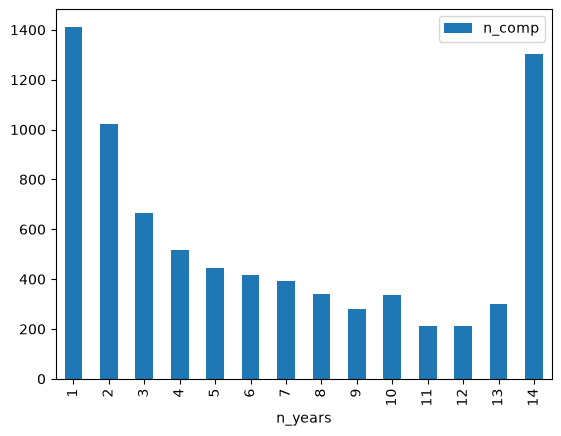

In [66]:
# first we compute how many years each firm has data for
firm_n_years = data.groupby('gvkey').agg(
    n_years = ('year', 'count')
).reset_index()

# then given above dataset, we count how many firms have data for 1 year, 2 years, etc.
firm_n_years.groupby('n_years').agg(
    n_comp = ('gvkey', 'count')
).plot(kind='bar')

plt.show()

# Firm size - employment and ai employment


takeaways: 

    ai employment ratio 
    - ai employment ratio log mean increases over time as well as the number of ai firms. 
    - log variance remain quite similar and stablize over the years 
    - that means we can see a general increase in ai employment over total employment 
    

### Employment in General

box plots below show that firms size is generally bigger on average for firms that employ ai specific employees
one reason could be that firms of bigger size have more resources to invest in ai technology and training 

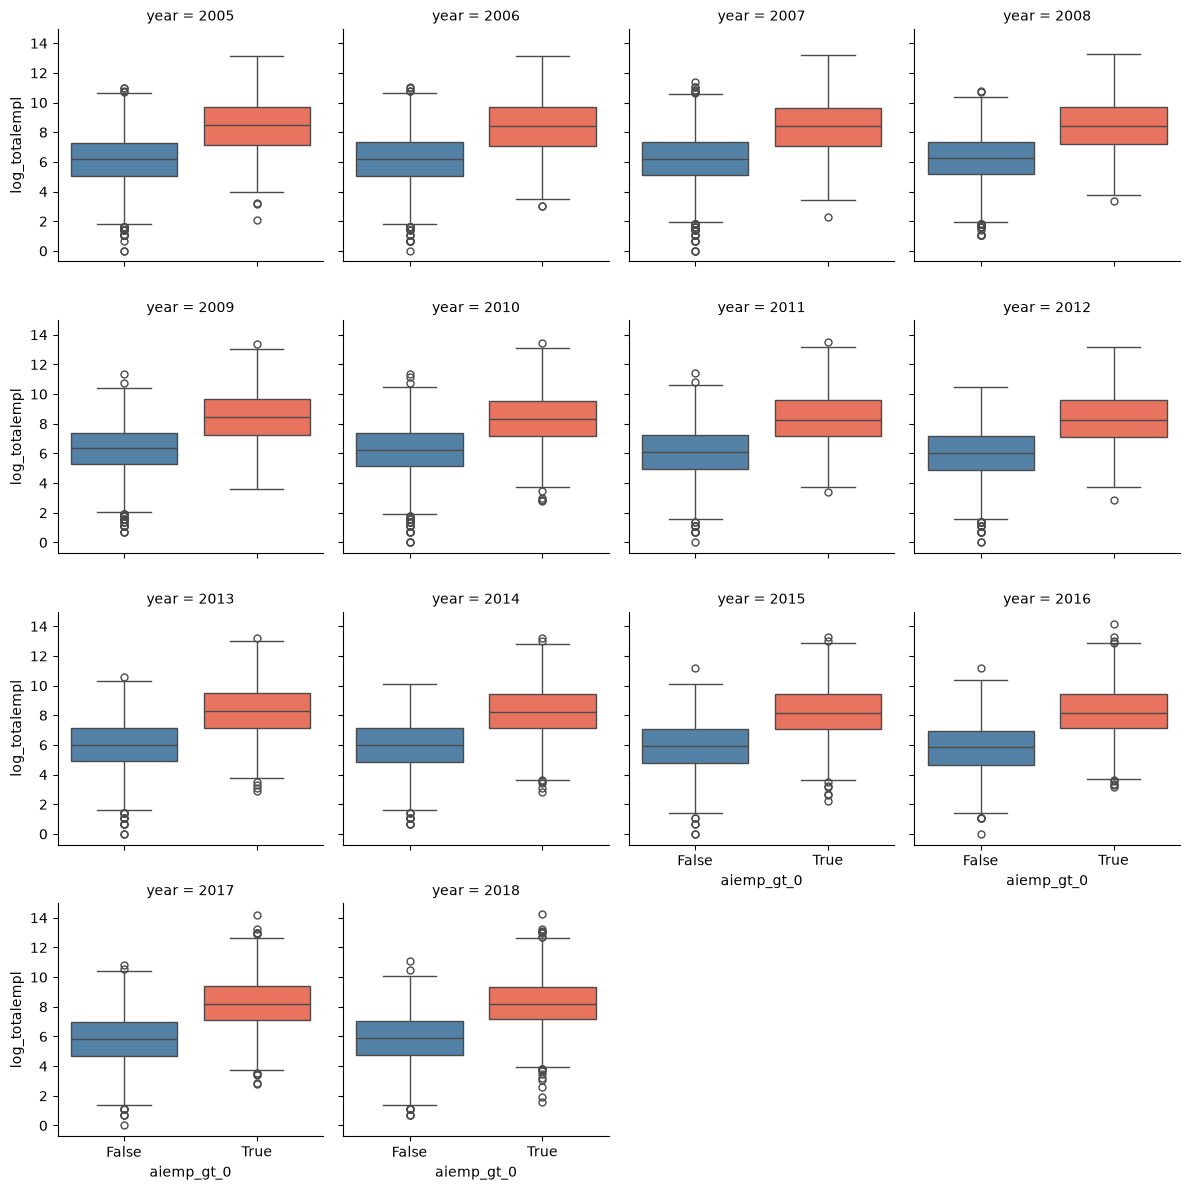

In [32]:
sns.catplot(
    data=data,
    x="aiemp_gt_0",
    y="log_totalempl",
    col="year",
    kind="box",
    col_wrap=4,
    height=3,
    palette={
        0: "steelblue",
        1: "tomato"
    },
    legend=False,
    hue="aiemp_gt_0"
)
plt.show()

In [33]:
data.groupby(['year','aiemp_gt_0'])['log_totalempl'].describe()

count      mean       std       min       25%       50%  \
year aiemp_gt_0                                                             
2005 False       3164.0  6.148041  1.665930  0.000000  5.075174  6.187236   
     True         704.0  8.420630  1.862374  2.079442  7.146575  8.500249   
2006 False       3035.0  6.155908  1.672444  0.000000  5.068904  6.196444   
     True         782.0  8.389493  1.852374  3.044522  7.070511  8.451267   
2007 False       2882.0  6.194652  1.652357  0.000000  5.129899  6.222574   
     True         862.0  8.373595  1.807666  2.302585  7.066018  8.403576   
2008 False       2681.0  6.228370  1.628612  1.098612  5.164786  6.289716   
     True         913.0  8.454830  1.747692  3.367296  7.178545  8.437067   
2009 False       2535.0  6.288916  1.607121  0.693147  5.257495  6.380123   
     True         959.0  8.457132  1.718352  3.610918  7.214136  8.454892   
2010 False       2627.0  6.171771  1.663425  0.000000  5.129899  6.216606   
     True        1056.0  8.366206  1.747768  2.772589  7.141829  8.344386   
2011 False       2650.0  6.089069  1.666097  0.000000  4.969813  6.119197   
     True        1146.0  8.359895  1.712692  3.367296  7.161816  8.257512   
2012 False       2561.0  6.000376  1.662082  0.000000  4.890349  6.040255   
     True        1265.0  8.338788  1.698845  2.833213  7.129298  8.255049   
2013 False       2397.0  5.974598  1.652484  0.000000  4.912655  6.018593   
     True        1378.0  8.303395  1.712895  2.890372  7.146575  8.269885   
2014 False       2223.0  5.956318  1.596609  0.693147  4.859812  6.013715   
     True        1485.0  8.276641  1.716597  2.833213  7.133296  8.246958   
2015 False       2019.0  5.867331  1.633044  0.000000  4.774904  5.934894   
     True        1567.0  8.211716  1.743058  2.197225  7.076654  8.179760   
2016 False       1867.0  5.784546  1.615513  0.000000  4.634729  5.831882   
     True        1586.0  8.247750  1.703010  3.135494  7.111920  8.181860   
2017 False       1714.0  5.781961  1.619458  0.000000  4.656330  5.800606   
     True        1585.0  8.245849  1.714271  2.772589  7.115582  8.190632   
2018 False       1430.0  5.854826  1.588388  0.693147  4.720721  5.894403   
     True        1549.0  8.235095  1.721051  1.609438  7.160069  8.192017   

                      75%        max  
year aiemp_gt_0                       
2005 False       7.305356  10.978746  
     True        9.691407  13.109244  
2006 False       7.315551  11.020005  
     True        9.677399  13.165521  
2007 False       7.338400  11.385808  
     True        9.631053  13.226705  
2008 False       7.355002  10.764604  
     True        9.706499  13.297682  
2009 False       7.397559  11.388156  
     True        9.659240  13.368969  
2010 False       7.348266  11.386205  
     True        9.562508  13.464451  
2011 False       7.269617  11.399040  
     True        9.571315  13.541858  
2012 False       7.164720  10.492329  
     True        9.573941  13.198641  
2013 False       7.152269  10.555135  
     True        9.497866  13.216657  
2014 False       7.134492  10.113911  
     True        9.465603  13.231862  
2015 False       7.071572  11.200882  
     True        9.414871  13.255334  
2016 False       6.961296  11.163878  
     True        9.407237  14.135214  
2017 False       6.968850  10.838463  
     True        9.401209  14.196238  
2018 False       7.016154  11.118712  
     True        9.353401  14.255405

### AI Employment

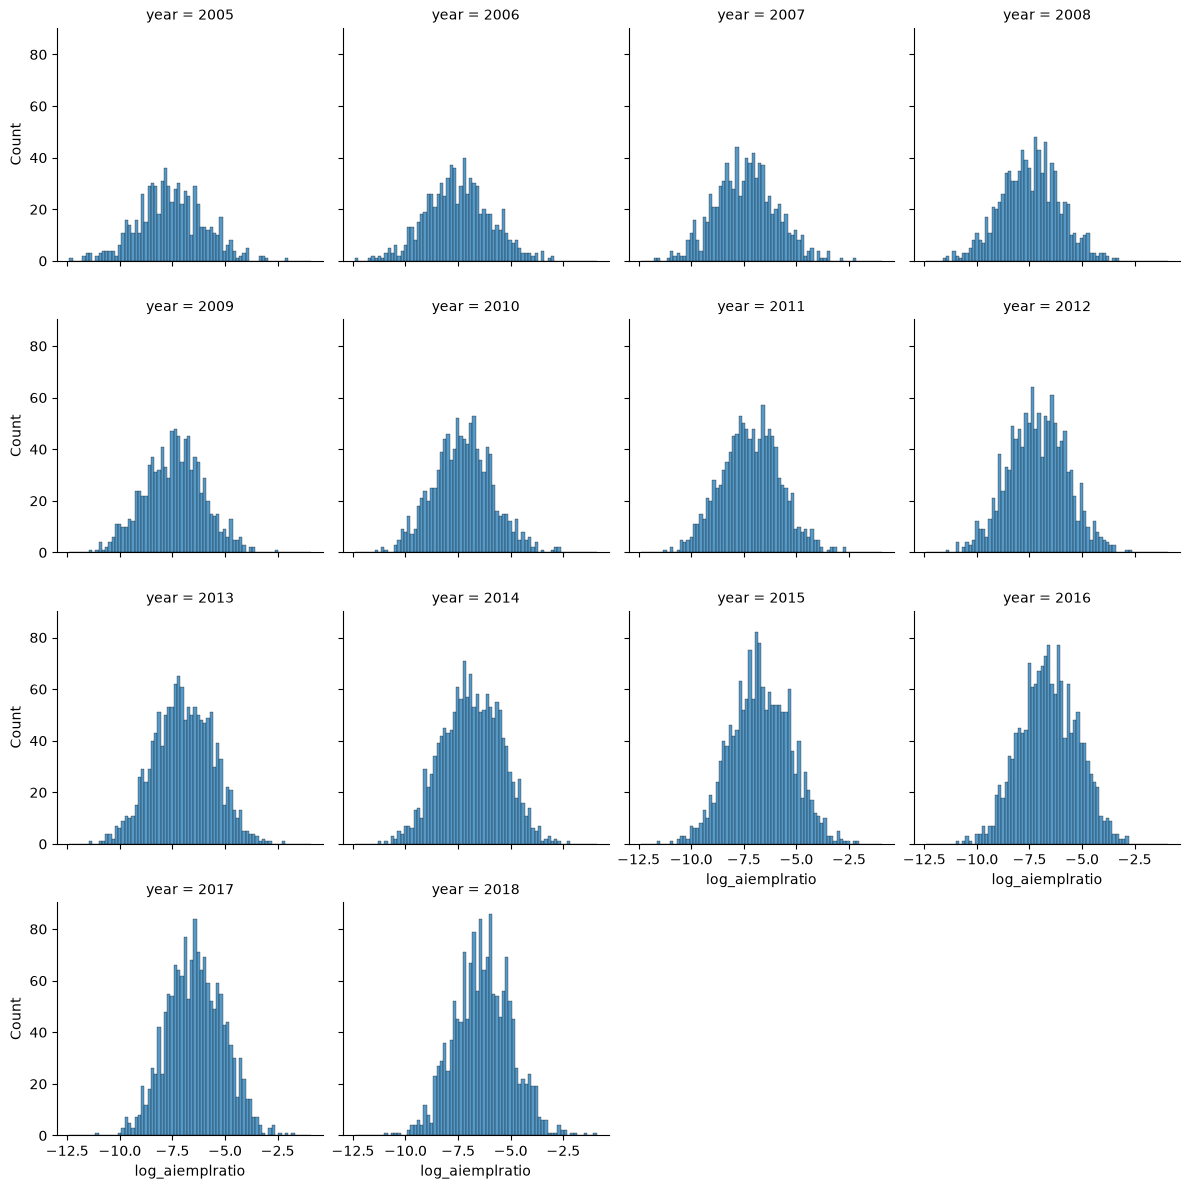

In [29]:
sns.displot(
    data=data[data['aiemp_gt_0']], 
    x='log_aiemplratio', 
    col="year",
    col_wrap=4,
    height=3,
    kind="hist"

)

In [30]:
summary = (
    data[data['aiemp_gt_0']]
    .groupby("year")["log_aiemplratio"]
    .agg(
        mean="mean",
        variance="var",
        std="std",
        median="median",
        n="count"
    )
)

print(summary)

          mean  variance       std    median     n
year                                              
2005 -7.563326  2.461776  1.569005 -7.640081   704
2006 -7.484059  2.360727  1.536466 -7.521270   782
2007 -7.411531  2.116666  1.454877 -7.378128   862
2008 -7.447754  1.965856  1.402090 -7.436617   913
2009 -7.418549  1.974916  1.405317 -7.393878   959
2010 -7.266177  1.958377  1.399420 -7.271008  1056
2011 -7.174024  1.925388  1.387583 -7.173958  1146
2012 -7.108911  1.941513  1.393382 -7.121252  1265
2013 -6.980263  2.010015  1.417750 -7.023091  1378
2014 -6.837858  2.051811  1.432414 -6.840547  1485
2015 -6.694744  2.038958  1.427921 -6.725034  1567
2016 -6.585853  1.857364  1.362851 -6.606987  1586
2017 -6.400343  1.796634  1.340386 -6.413459  1585
2018 -6.320457  1.828865  1.352355 -6.331776  1549


# Revenue

the following shows box plots comparing revenue between ai and non ai companies. it as quite apparent, that we cant see any differences, statistical test yet to be performed. 

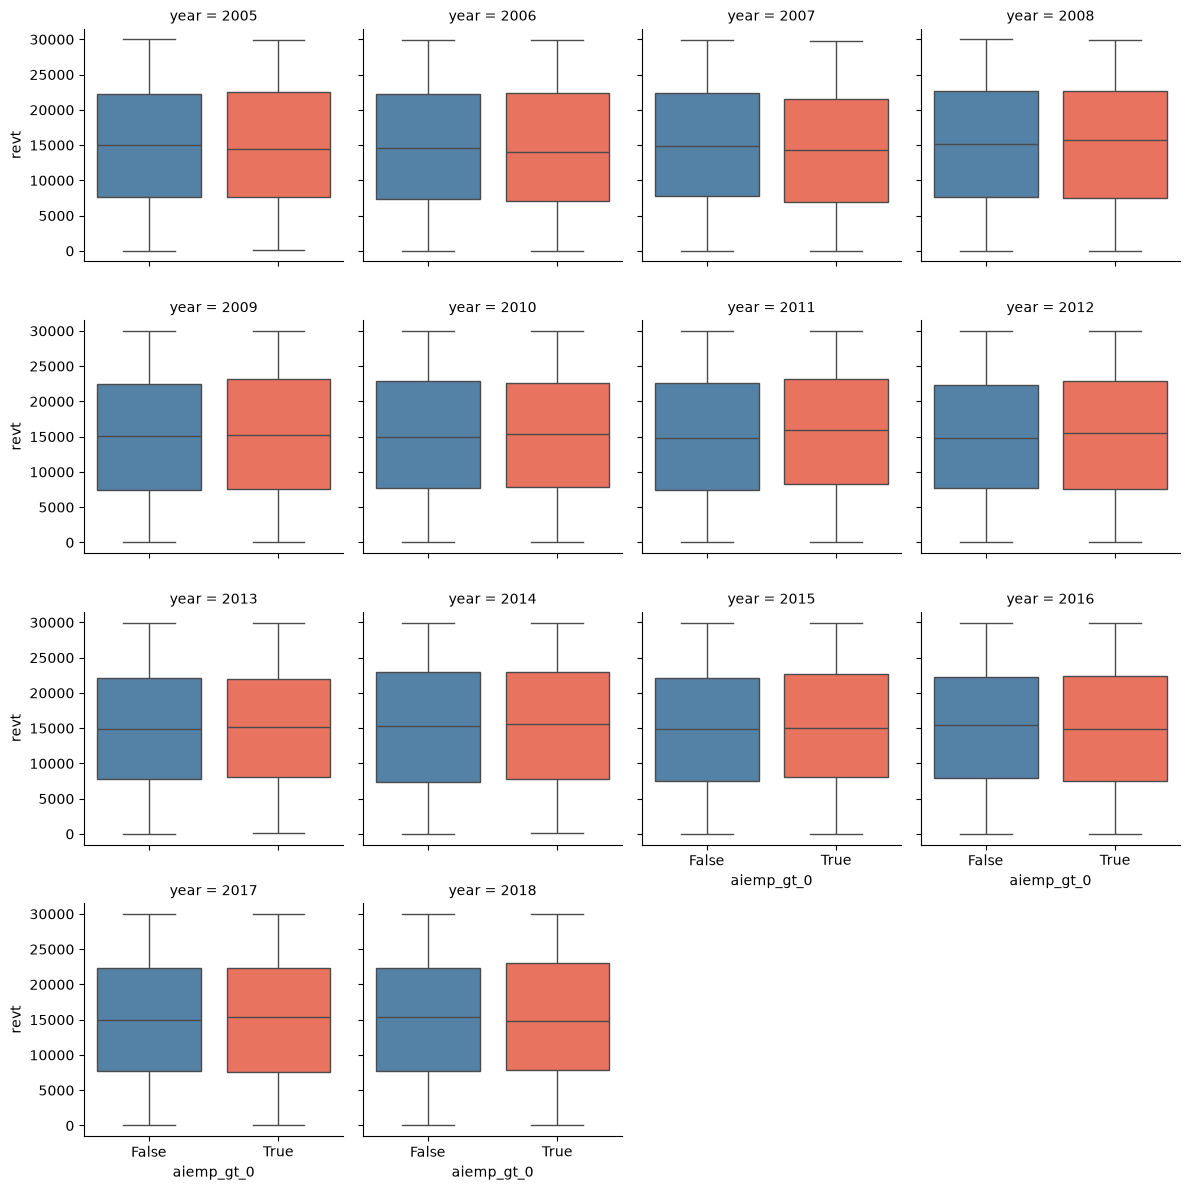

In [ ]:
sns.catplot(
    data=data,
    x="aiemp_gt_0",
    y="revt",
    col="year",
    kind="box",
    col_wrap=4,
    height=3,
    palette={
        0: "steelblue",
        1: "tomato"
    },
    legend=False,
    hue="aiemp_gt_0"
)
plt.show()

# prcc_f 

In [71]:
data[['prcc_f', 'prcc_c']].head(5)

,prcc_f,prcc_c
0,41.338600,48.507757
1,108.254171,62.312689
2,31.835774,66.897285
3,68.780786,40.511961
4,96.134525,113.095116
